# Impact of the COVID-19 Pandemic on Market Sectors (2018–2023)

### Exploratory Market Analysis and Dimensional Data Modeling

This project analyzes the development of four market sectors — **Technology, Pharmaceuticals, Travel, and Entertainment** — before, during, and after the COVID-19 pandemic.

Historical daily market data is downloaded from Yahoo Finance for **24 stocks and ETFs** covering the period from January 2018 to December 2023.

The notebook has two main goals:

- perform an exploratory data analysis (EDA) to compare sector and company performance;
- prepare a clean star schema for downstream analysis in SQL and for the project's interactive Power BI dashboard.

The analysis focuses on relative performance, total returns, individual asset performance, and differences between the **Pre-COVID, COVID, and Post-COVID** periods.


## 1. Import Libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


In [2]:
# Consistent colors for sector-based visualizations
SECTOR_COLORS = {
    "Technology": "#3B5BA9",
    "Pharmaceuticals": "#2A9D8F",
    "Travel": "#E9A03B",
    "Entertainment": "#C8553D"
}

## 2. Define Market Sectors and Assets

Each sector contains six assets. Technology, Pharmaceuticals, and Travel include five companies and one sector ETF. Entertainment contains six individual companies.


In [3]:
# Define Technology assets and Yahoo Finance ticker symbols
technology = {
    "Microsoft": "MSFT",
    "NVIDIA": "NVDA",
    "Adobe": "ADBE",
    "Salesforce": "CRM",
    "Cisco": "CSCO",
    "Technology Select Sector SPDR ETF": "XLK"
}

# Define Pharmaceutical assets
pharmaceuticals = {
    "Pfizer": "PFE",
    "AbbVie": "ABBV",
    "Abbott Laboratories": "ABT",
    "Johnson & Johnson": "JNJ",
    "Eli Lilly": "LLY",
    "Health Care Select Sector SPDR ETF": "XLV"
}

# Define Travel assets
travel = {
    "Booking Holdings": "BKNG",
    "Expedia": "EXPE",
    "Marriott": "MAR",
    "Delta Air Lines": "DAL",
    "Carnival": "CCL",
    "U.S. Global Jets ETF": "JETS"
}

# Define Entertainment assets
entertainment = {
    "Netflix": "NFLX",
    "Disney": "DIS",
    "Warner Bros. Discovery": "WBD",
    "Take-Two Interactive": "TTWO",
    "Live Nation Entertainment": "LYV",
    "Comcast": "CMCSA"
}

# Combine all sectors
assets = {
    "Technology": technology,
    "Pharmaceuticals": pharmaceuticals,
    "Travel": travel,
    "Entertainment": entertainment
}

# Create one asset table
rows = []

for sector, companies in assets.items():
    for company, ticker in companies.items():
        rows.append([sector, company, ticker])

df_assets = pd.DataFrame(
    rows,
    columns=["Sector", "Company", "Ticker"]
)

df_assets


,Sector,Company,Ticker
0,Technology,Microsoft,MSFT
1,Technology,NVIDIA,NVDA
2,Technology,Adobe,ADBE
3,Technology,Salesforce,CRM
4,Technology,Cisco,CSCO
5,Technology,Technology Select Sector SPDR ETF,XLK
6,Pharmaceuticals,Pfizer,PFE
7,Pharmaceuticals,AbbVie,ABBV
8,Pharmaceuticals,Abbott Laboratories,ABT
9,Pharmaceuticals,Johnson & Johnson,JNJ


## 3. Download Historical Market Data

Daily market data is downloaded from Yahoo Finance from **2018-01-01** to **2024-01-01**. The end date is exclusive, so the dataset covers the full 2018–2023 analysis period.

`auto_adjust=True` is set explicitly so adjusted OHLC prices are used consistently.


In [4]:
# Create the ticker list used for the Yahoo Finance download
ticker_list = df_assets["Ticker"].tolist()

# Download historical data for all selected stocks and ETFs
all_data = yf.download(
    ticker_list,
    start="2018-01-01",
    end="2024-01-01",
    auto_adjust=True
)

all_data


[*********************100%***********************]  24 of 24 completed


Price            Close                                                 \
Ticker            ABBV         ABT        ADBE        BKNG        CCL   
Date                                                                    
2018-01-02   68.287102   50.148411  177.699997   69.736649  60.468700   
2018-01-03   69.355713   50.259289  181.039993   71.276550  60.604572   
2018-01-04   68.960175   50.174000  183.220001   70.615822  60.559292   
2018-01-05   70.160629   50.319008  185.339996   71.252319  60.061050   
2018-01-08   69.036499   50.174000  185.039993   72.356941  59.834572   
...                ...         ...         ...         ...        ...   
2023-12-22  141.090134  102.994812  598.750000  138.152588  18.630613   
2023-12-26  140.798706  103.183731  598.260010  139.361969  18.315674   
2023-12-27  141.035446  103.712753  596.080017  138.111191  18.246782   
2023-12-28  140.917084  104.288979  595.520020  138.729721  18.374723   
2023-12-29  141.117416  103.977249  596.599976  138.602722  18.246782   

Price                                                                ...  \
Ticker          CMCSA         CRM       CSCO        DAL         DIS  ...   
Date                                                                 ...   
2018-01-02  30.406322  102.634377  30.156704  51.660381  105.416786  ...   
2018-01-03  29.917679  103.499405  30.397282  50.704384  105.869370  ...   
2018-01-04  30.110178  104.865768  30.483286  50.704384  105.822235  ...   
2018-01-05  30.384108  106.261627  30.905474  50.959305  105.247063  ...   
2018-01-08  29.969511  107.008682  31.226025  49.784809  103.738396  ...   
...               ...         ...        ...        ...         ...  ...   
2023-12-22  37.184544  261.810577  46.611790  39.895584   88.537247  ...   
2023-12-26  37.125381  261.692627  46.788605  39.536682   88.469170  ...   
2023-12-27  37.176094  262.184143  46.937489  39.371784   87.914711  ...   
2023-12-28  37.285954  261.063446  46.974716  39.410583   87.934174  ...   
2023-12-29  37.057774  258.665009  47.011932  39.022591   87.827164  ...   

Price        Volume                                                     \
Ticker          LYV      MAR      MSFT       NFLX       NVDA       PFE   
Date                                                                     
2018-01-02   926800  2949200  22483800  109669000  355616000  17059833   
2018-01-03  1252400  1507900  26061400   85914000  914704000  14183151   
2018-01-04  1265400  3187000  21912000   60296000  583268000  13046517   
2018-01-05  1070900  3404400  23407100   70332000  580124000  13167517   
2018-01-08   973900  3275500  22113000   55802000  881216000  19964341   
...             ...      ...       ...        ...        ...       ...   
2023-12-22  1863000   995000  17107500   27027000  252507000  35162300   
2023-12-26  1105600  1118600  12673100   20345000  244200000  30119100   
2023-12-27  2051000  1329600  14905400   25613000  233648000  35000700   
2023-12-28  1683600   971000  14327000   17105000  246587000  30472900   
2023-12-29  1612700  2008700  18730800   27406000  389293000  30363100   

Price                                             
Ticker         TTWO       WBD       XLK      XLV  
Date                                              
2018-01-02  1569300   5028200  27445600  6708900  
2018-01-03  1451500   5292900  22663600  7606500  
2018-01-04  1319300   7875900  21493200  7762500  
2018-01-05  1513600   8498800  19356000  7579300  
2018-01-08  1591400   4103800  13467800  5167300  
...             ...       ...       ...      ...  
2023-12-22  1347600  21560800  10215000  5355100  
2023-12-26   763300  17934500   6207600  3688600  
2023-12-27   936900  20714200  11764600  5444100  
2023-12-28   784900  16578600   9615400  5800200  
2023-12-29   916600  20267500  12190600  5590000  

[1509 rows x 120 columns]

## 4. Check Data Quality

Before the analysis, the dataset is checked for its date range, number of assets, number of observations, and missing values.


In [5]:
# Convert the wide Yahoo Finance structure to long format
df_long = (
    all_data
    .stack(level="Ticker", future_stack=True)
    .reset_index()
)

# Basic data quality checks
print("Date range:", df_long["Date"].min(), "to", df_long["Date"].max())
print("Assets:", df_long["Ticker"].nunique())
print("Observations:", len(df_long))
print("Missing values:", int(df_long.isna().sum().sum()))

df_long.head()


Date range: 2018-01-02 00:00:00 to 2023-12-29 00:00:00
Assets: 24
Observations: 36216
Missing values: 0


Price,Date,Ticker,Close,High,Low,Open,Volume
0,2018-01-02,ABBV,68.287102,68.627113,67.135218,67.405841,4561300
1,2018-01-02,ABT,50.148411,50.498144,49.320991,49.645135,10112800
2,2018-01-02,ADBE,177.699997,177.800003,175.259995,175.850006,2432800
3,2018-01-02,BKNG,69.736649,69.967578,68.163935,68.382358,11887500
4,2018-01-02,CCL,60.468700,60.930710,60.332814,60.894474,2783800


## 5. Build the EDA Dataset

Company and sector information is added to the long-format market data. This creates one analysis table that contains prices, company names, sectors, and dates.


In [6]:
# Add company and sector information to the market data
eda_data = df_long.merge(
    df_assets[["Ticker", "Company", "Sector"]],
    on="Ticker",
    how="left"
)

eda_data.head()


,Date,Ticker,Close,High,Low,Open,Volume,Company,Sector
0,2018-01-02,ABBV,68.287102,68.627113,67.135218,67.405841,4561300,AbbVie,Pharmaceuticals
1,2018-01-02,ABT,50.148411,50.498144,49.320991,49.645135,10112800,Abbott Laboratories,Pharmaceuticals
2,2018-01-02,ADBE,177.699997,177.800003,175.259995,175.850006,2432800,Adobe,Technology
3,2018-01-02,BKNG,69.736649,69.967578,68.163935,68.382358,11887500,Booking Holdings,Travel
4,2018-01-02,CCL,60.468700,60.930710,60.332814,60.894474,2783800,Carnival,Travel


## 6. Descriptive Overview


In [7]:
# Display descriptive statistics for the numerical market variables
eda_data.describe()


,Date,Close,High,Low,Open,Volume
count,36216,36216.000000,36216.000000,36216.000000,36216.000000,3.621600e+04
mean,2020-12-30 14:13:07.276341760,100.341650,101.516788,99.104199,100.333915,3.379414e+07
min,2018-01-02 00:00:00,3.143212,3.214941,3.078409,3.128619,1.000000e+03
25%,2019-07-03 00:00:00,35.180486,35.619142,34.713121,35.193924,3.474775e+06
50%,2020-12-30 00:00:00,77.854595,78.763914,77.001351,77.920039,7.626700e+06
75%,2022-06-30 00:00:00,126.813622,128.000000,125.509657,126.759420,2.009460e+07
max,2023-12-29 00:00:00,688.369995,699.539978,678.909973,696.280029,2.511528e+09
std,NaN,95.385467,96.467726,94.205229,95.363468,1.047830e+08


**Note:** These descriptive statistics should be interpreted with caution because the dataset contains different companies and ETFs with very different absolute price levels. They provide a general overview but are not suitable for direct performance comparisons between assets.


## 7. Review Sector Composition


In [8]:
# Print the companies and ETFs included in each sector
for sector, companies in eda_data.groupby("Sector")["Company"].unique().items():
    print(f"\n{sector}")
    for company in companies:
        print(f" - {company}")



Entertainment
 - Comcast
 - Disney
 - Live Nation Entertainment
 - Netflix
 - Take-Two Interactive
 - Warner Bros. Discovery

Pharmaceuticals
 - AbbVie
 - Abbott Laboratories
 - Johnson & Johnson
 - Eli Lilly
 - Pfizer
 - Health Care Select Sector SPDR ETF

Technology
 - Adobe
 - Salesforce
 - Cisco
 - Microsoft
 - NVIDIA
 - Technology Select Sector SPDR ETF

Travel
 - Booking Holdings
 - Carnival
 - Delta Air Lines
 - Expedia
 - U.S. Global Jets ETF
 - Marriott


## 8. Average Closing Price by Sector

The first sector-level view compares average closing prices over time. Because absolute share prices differ substantially between companies, this chart is used only as a general reference.


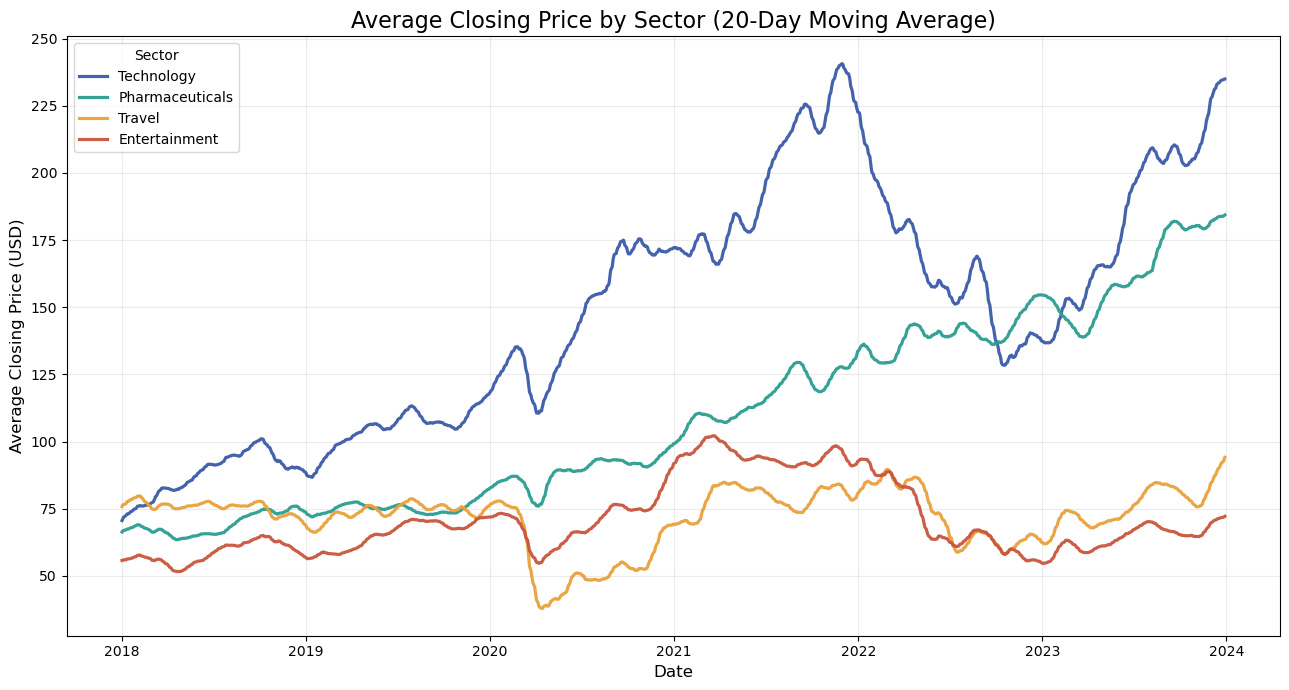

In [9]:
# Calculate the average closing price for each sector and date
sector_close = (
    eda_data
    .groupby(["Date", "Sector"])["Close"]
    .mean()
    .reset_index()
)

# Plot average closing prices with consistent colors and smoother lines
plt.figure(figsize=(13, 7))

sector_order = ["Technology", "Pharmaceuticals", "Travel", "Entertainment"]

for sector in sector_order:
    sector_data = (
        sector_close[sector_close["Sector"] == sector]
        .sort_values("Date")
        .copy()
    )

    # Smooth the line slightly with a rolling mean
    sector_data["Close_Smoothed"] = (
        sector_data["Close"]
        .rolling(window=20, min_periods=1)
        .mean()
    )

    plt.plot(
        sector_data["Date"],
        sector_data["Close_Smoothed"],
        label=sector,
        color=SECTOR_COLORS[sector],
        linewidth=2.3,
        alpha=0.95
    )

plt.title("Average Closing Price by Sector (20-Day Moving Average)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Closing Price (USD)", fontsize=12)
plt.legend(title="Sector", frameon=True)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

**Note:** A higher average share price does not automatically indicate stronger sector performance. The companies have very different price levels, so normalized values and percentage returns are more useful for comparison.


## 9. Normalize Sector Performance

To compare sector performance fairly, each asset is first normalized individually to a starting value of 100. The six normalized asset series within each sector are then averaged. This creates an **equal-weighted sector index**, so every asset contributes equally regardless of its absolute share price.


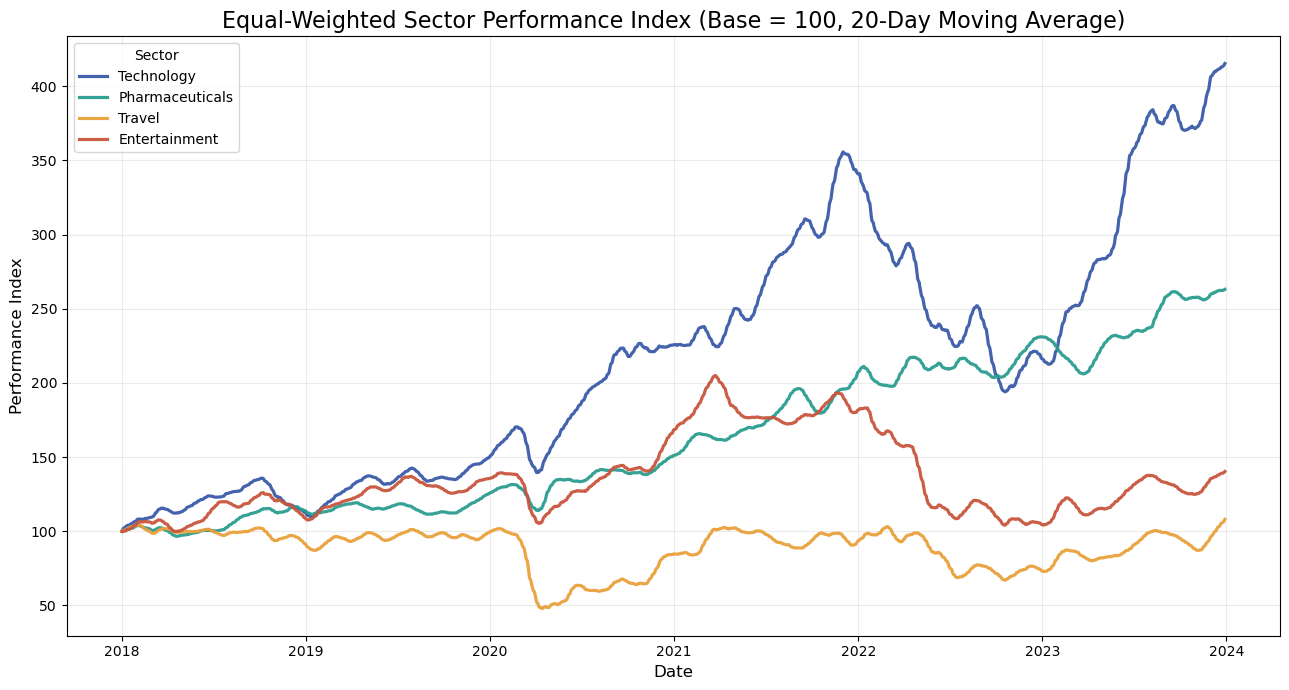

In [10]:
# Normalize each asset individually to a base value of 100
asset_index_data = (
    eda_data
    .sort_values(["Ticker", "Date"])
    .copy()
)

asset_index_data["AssetIndex"] = (
    asset_index_data
    .groupby("Ticker")["Close"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

# Calculate the equal-weighted sector index
sector_index = (
    asset_index_data
    .groupby(["Date", "Sector"])["AssetIndex"]
    .mean()
    .unstack("Sector")
    .sort_index()
)

# Plot normalized sector performance
plt.figure(figsize=(13, 7))

sector_order = ["Technology", "Pharmaceuticals", "Travel", "Entertainment"]

for sector in sector_order:
    # Smooth the normalized performance line with a 20-day moving average
    smoothed_index = (
        sector_index[sector]
        .rolling(window=20, min_periods=1)
        .mean()
    )

    plt.plot(
        sector_index.index,
        smoothed_index,
        label=sector,
        color=SECTOR_COLORS[sector],
        linewidth=2.3,
        alpha=0.95
    )

plt.title(
    "Equal-Weighted Sector Performance Index (Base = 100, 20-Day Moving Average)",
    fontsize=16
)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Performance Index", fontsize=12)
plt.legend(title="Sector")
plt.grid(True, alpha=0.25)
plt.tight_layout()

plt.show()


**Interpretation:** Because every asset is normalized before the sector average is calculated, each company or ETF receives the same weight within its sector. Technology shows the strongest development over the full period. Travel experienced the sharpest decline during the initial COVID shock and finished with the weakest full-period equal-weighted return.


## 10. Calculate Total Return by Sector

The full-period sector return is calculated from the first and last values of the **equal-weighted sector index**:

`(Ending Value / Starting Value − 1) × 100`


In [11]:
# Calculate total return from the equal-weighted sector index
sector_return = (
    (sector_index.iloc[-1] / sector_index.iloc[0] - 1) * 100
).round(2)

sector_return


Sector
Entertainment       43.10
Pharmaceuticals    166.06
Technology         322.37
Travel              11.41
dtype: float64

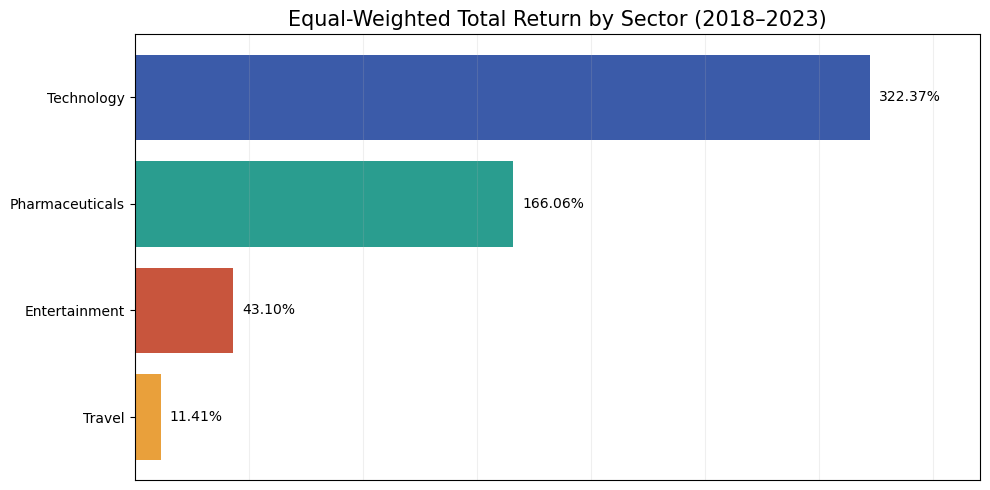

In [12]:
# Sort sector returns
sorted_return = sector_return.sort_values()

# Use the predefined sector colors
colors = [
    SECTOR_COLORS[sector]
    for sector in sorted_return.index
]

# Plot horizontally
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    sorted_return.index,
    sorted_return.values,
    color=colors
)

plt.title("Equal-Weighted Total Return by Sector (2018–2023)", fontsize=15)
plt.xlabel("")
plt.ylabel("")

# Remove x-axis numbers and tick marks
ax.tick_params(
    axis="x",
    bottom=False,
    labelbottom=False
)

# Keep subtle grid lines
plt.grid(axis="x", alpha=0.2)

# Add extra space on the right for labels
ax.set_xlim(0, sorted_return.max() * 1.15)

# Add return values outside the bars
for bar, value in zip(bars, sorted_return.values):
    ax.text(
        value + 4,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        ha="left",
        va="center",
        color="black",
        fontweight="normal",
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Interpretation:** Using equal weighting, Technology remains the strongest sector at approximately **322%**, followed by Pharmaceuticals at about **166%**. Entertainment reaches approximately **43%**, while Travel ends the period at about **11%**. Equal weighting prevents high-priced shares from dominating the sector result.


## 11. Compare Individual Asset Performance

The same total-return calculation is applied to every company and ETF to identify the strongest and weakest performers.


In [13]:
# Calculate first and last closing prices for each company
company_return = (
    eda_data
    .sort_values("Date")
    .groupby("Company")["Close"]
    .agg(["first", "last"])
)

# Calculate total return and sort from highest to lowest
company_return["Return"] = (
    (company_return["last"] / company_return["first"] - 1) * 100
)

company_return = company_return["Return"].sort_values(ascending=False)

company_return


Company
NVIDIA                                904.242693
Eli Lilly                             664.920370
Microsoft                             368.708268
Adobe                                 235.734376
Technology Select Sector SPDR ETF     217.594598
Salesforce                            152.025703
Netflix                               142.144521
Live Nation Entertainment             119.460715
Abbott Laboratories                   107.339071
AbbVie                                106.653105
Booking Holdings                       98.751625
Health Care Select Sector SPDR ETF     80.667676
Marriott                               76.703920
Cisco                                  55.892144
Take-Two Interactive                   42.585047
Johnson & Johnson                      32.387506
Expedia                                28.247551
Comcast                                21.875224
Pfizer                                  4.421336
Disney                                -16.685789
Delta Air Li

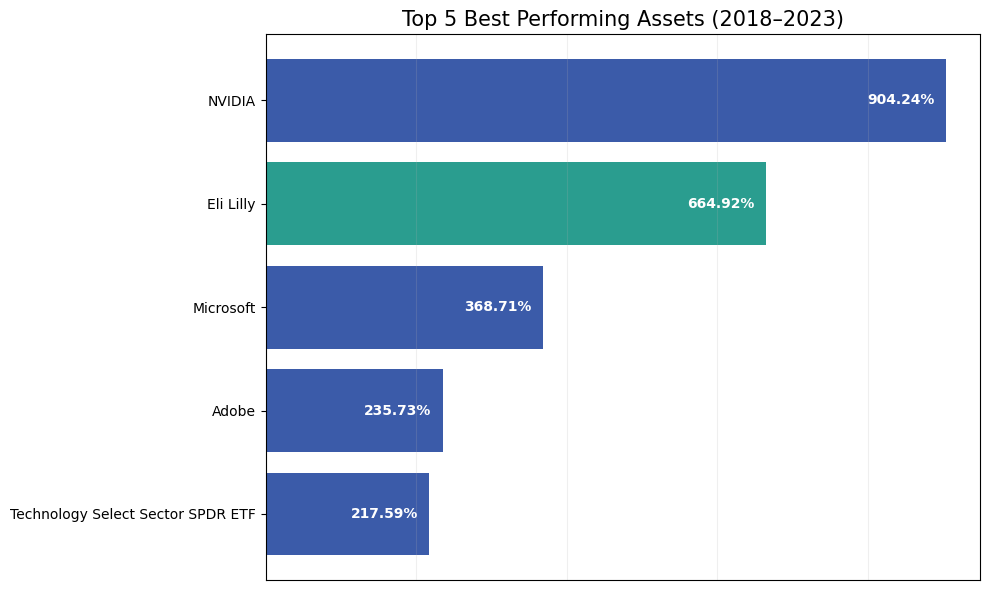

In [14]:
# Select the five best performing assets
top5 = company_return.head(5)

# Map each company to its sector
company_sector = (
    df_assets
    .set_index("Company")["Sector"]
)

# Use the predefined sector colors
colors = [
    SECTOR_COLORS[company_sector[company]]
    for company in top5.index
]

# Plot horizontally
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top5.index,
    top5.values,
    color=colors
)

# Highest return at the top
ax.invert_yaxis()

plt.title("Top 5 Best Performing Assets (2018–2023)", fontsize=15)
plt.xlabel("")
plt.ylabel("")

# Remove x-axis numbers and tick marks
ax.tick_params(
    axis="x",
    bottom=False,
    labelbottom=False
)

# Keep subtle grid lines
plt.grid(axis="x", alpha=0.2)

# Add return values inside the bars
for bar, value in zip(bars, top5.values):
    ax.text(
        value - 15,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        ha="right",
        va="center",
        color="white",
        fontweight="bold",
        fontsize=10
    )

plt.tight_layout()
plt.show()


**Interpretation:** NVIDIA is the strongest performer over the full period, followed by Eli Lilly and Microsoft. These results cannot be attributed to the pandemic alone; later developments such as the AI boom and company-specific factors also influenced performance.


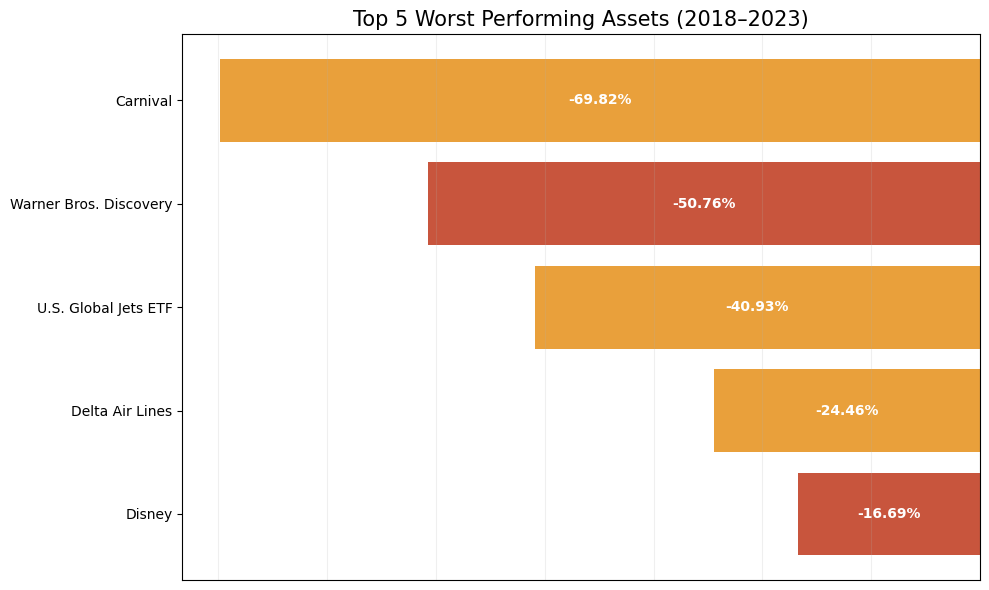

In [15]:
# Select the five worst performing assets
bottom5_sorted = company_return.nsmallest(5)

# Map each company to its sector
company_sector = (
    df_assets
    .set_index("Company")["Sector"]
)

# Use the predefined sector colors
colors = [
    SECTOR_COLORS[company_sector[company]]
    for company in bottom5_sorted.index
]

# Plot horizontally
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    bottom5_sorted.index,
    bottom5_sorted.values,
    color=colors
)

# Worst performer at the top
ax.invert_yaxis()

plt.title("Top 5 Worst Performing Assets (2018–2023)", fontsize=15)
plt.xlabel("")
plt.ylabel("")

# Remove x-axis numbers and tick marks
ax.tick_params(
    axis="x",
    bottom=False,
    labelbottom=False
)

# Subtle grid
ax.grid(axis="x", alpha=0.2)

# Add values exactly in the center of each bar
for bar, value in zip(bars, bottom5_sorted.values):
    ax.text(
        bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Interpretation:** Carnival and Warner Bros. Discovery are the weakest performers in the selected universe. The lower-performing group also includes the travel ETF, Delta Air Lines, and Disney.


## 12. Define Pre-COVID, COVID, and Post-COVID Periods

For a consistent comparison, the six-year analysis period is divided into three two-year phases:

- **Pre-COVID:** 2018–2019
- **COVID:** 2020–2021
- **Post-COVID:** 2022–2023

This is an analytical simplification rather than an econometrically identified structural break.


In [16]:
# Assign each observation to one of the three analysis periods
eda_data["Period"] = "Post-COVID"

eda_data.loc[
    eda_data["Date"] < "2020-01-01",
    "Period"
] = "Pre-COVID"

eda_data.loc[
    (eda_data["Date"] >= "2020-01-01") &
    (eda_data["Date"] < "2022-01-01"),
    "Period"
] = "COVID"

# Check the number of observations in each period
eda_data["Period"].value_counts()


Period
COVID         12120
Pre-COVID     12072
Post-COVID    12024
Name: count, dtype: int64

## 13. Calculate Company Returns by Period

Returns are calculated separately for every company within each of the three analysis periods.


In [17]:
# Calculate first and last closing prices for every company in each period
company_period_return = (
    eda_data
    .sort_values("Date")
    .groupby(["Period", "Sector", "Company"])["Close"]
    .agg(["first", "last"])
    .reset_index()
)

# Calculate percentage return for each company and period
company_period_return["Return"] = (
    (company_period_return["last"] / company_period_return["first"] - 1) * 100
)

company_period_return = company_period_return[
    ["Period", "Sector", "Company", "Return"]
]

company_period_return.head(10)


,Period,Sector,Company,Return
0,COVID,Entertainment,Comcast,15.460580
1,COVID,Entertainment,Disney,4.514167
2,COVID,Entertainment,Live Nation Entertainment,66.490476
3,COVID,Entertainment,Netflix,82.662749
4,COVID,Entertainment,Take-Two Interactive,45.576670
5,COVID,Entertainment,Warner Bros. Discovery,-26.939789
6,COVID,Pharmaceuticals,AbbVie,67.224651
7,COVID,Pharmaceuticals,Abbott Laboratories,66.956393
8,COVID,Pharmaceuticals,Eli Lilly,116.344583
9,COVID,Pharmaceuticals,Health Care Select Sector SPDR ETF,42.418219


## 14. Compare Sector Returns Across Periods

Company returns are averaged within each sector to compare how the four sectors performed before, during, and after the pandemic.


In [18]:
# Calculate average company return within each sector and period
sector_period_return = (
    company_period_return
    .groupby(["Period", "Sector"])["Return"]
    .mean()
    .reset_index()
)

sector_period_return


,Period,Sector,Return
0,COVID,Entertainment,31.294142
1,COVID,Pharmaceuticals,64.724401
2,COVID,Technology,125.834800
3,COVID,Travel,-6.397816
4,Post-COVID,Entertainment,-26.181504
5,Post-COVID,Pharmaceuticals,12.975653
6,Post-COVID,Technology,14.078956
7,Post-COVID,Travel,6.735418
8,Pre-COVID,Entertainment,37.549818
9,Pre-COVID,Pharmaceuticals,27.857118


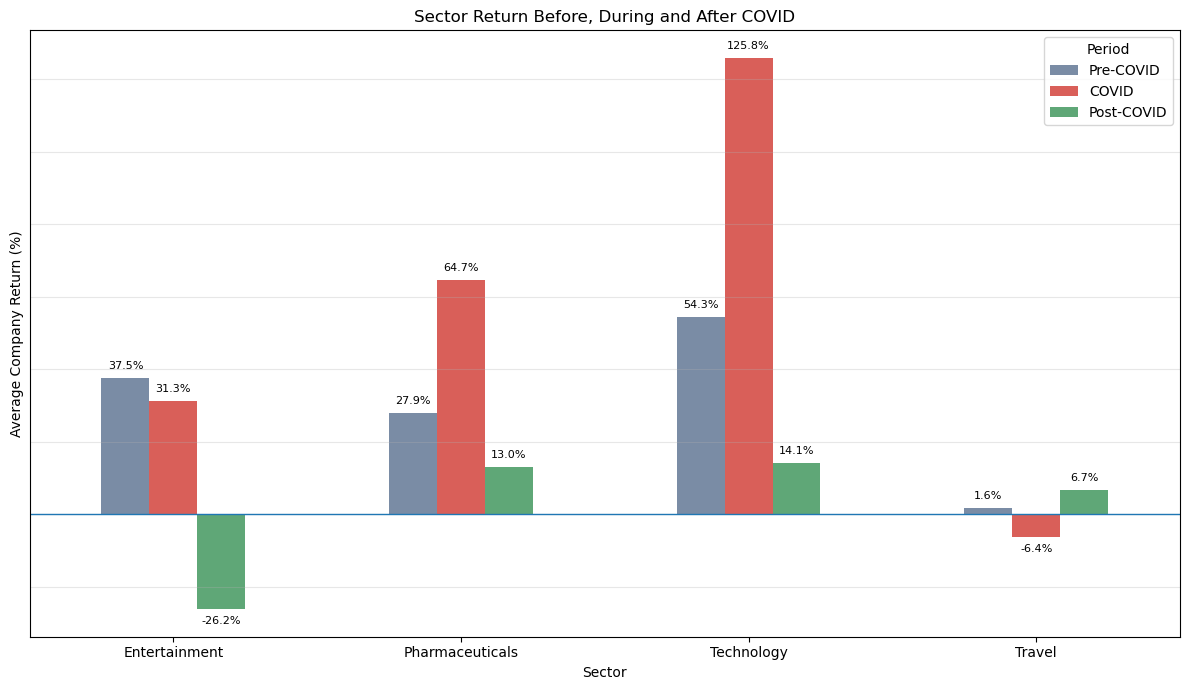

In [19]:
# Define the logical period order
period_order = ["Pre-COVID", "COVID", "Post-COVID"]

# Reshape the data for a grouped bar chart
period_pivot = sector_period_return.pivot(
    index="Sector",
    columns="Period",
    values="Return"
)

period_pivot = period_pivot[period_order]

# Define consistent colors for the three periods
PERIOD_COLORS = {
    "Pre-COVID": "#7A8CA5",
    "COVID": "#D95F59",
    "Post-COVID": "#5FA777"
}

colors = [
    PERIOD_COLORS[period]
    for period in period_pivot.columns
]

# Plot sector returns across the three periods
ax = period_pivot.plot(
    kind="bar",
    figsize=(12, 7),
    color=colors
)

plt.title("Sector Return Before, During and After COVID")
plt.xlabel("Sector")
plt.ylabel("Average Company Return (%)")
plt.xticks(rotation=0)

# Keep horizontal grid lines
plt.grid(axis="y", alpha=0.3)

# Add a zero line
plt.axhline(0, linewidth=1)

# Remove y-axis numbers and tick marks
ax.tick_params(
    axis="y",
    left=False,
    labelleft=False
)

# Add percentage values directly to the bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=5,
        fontsize=8
    )

plt.legend(title="Period")
plt.tight_layout()
plt.show()


**Interpretation:** Technology produced the highest average return during the COVID period at approximately **126%**, followed by Pharmaceuticals at about **65%**. Travel was the only sector with a negative average return during this phase. Entertainment produced an average return of about **31%** during the COVID period but declined by roughly **26%** in the Post-COVID period.

## 15. Analyze Sector Volatility

Return alone does not show how much an investment fluctuated over time.  
To compare the risk characteristics of the four sectors, daily returns are calculated for each asset and then averaged within each sector.

Annualized volatility is calculated as:

`Standard Deviation of Daily Returns × √252`

where 252 represents the approximate number of trading days in one year.

A higher volatility indicates larger price fluctuations and therefore greater market risk.

In [20]:
# Sort the data before calculating daily returns
volatility_data = eda_data.sort_values(
    ["Ticker", "Date"]
).copy()

# Calculate daily returns for each asset
volatility_data["DailyReturn"] = (
    volatility_data
    .groupby("Ticker")["Close"]
    .pct_change()
)

# Calculate the equal-weighted average daily return for each sector
sector_daily_return = (
    volatility_data
    .groupby(["Date", "Sector"])["DailyReturn"]
    .mean()
    .reset_index()
)

# Calculate annualized volatility for each sector
sector_volatility = (
    sector_daily_return
    .groupby("Sector")["DailyReturn"]
    .std()
    .mul(252 ** 0.5)
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

sector_volatility

Sector
Travel             39.17
Technology         29.97
Entertainment      26.99
Pharmaceuticals    19.09
Name: DailyReturn, dtype: float64

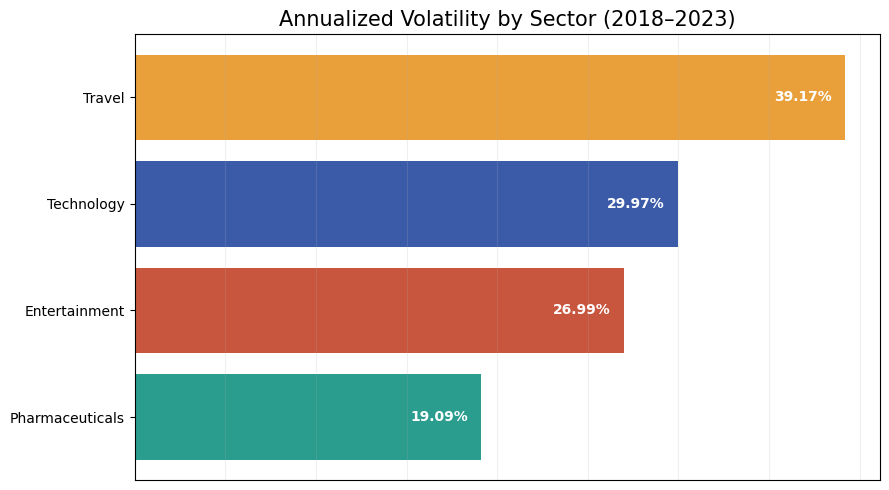

In [21]:
# Sort annualized volatility
sorted_volatility = sector_volatility.sort_values()

# Use the predefined sector colors
colors = [
    SECTOR_COLORS[sector]
    for sector in sorted_volatility.index
]

# Plot horizontally
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    sorted_volatility.index,
    sorted_volatility.values,
    color=colors
)

plt.title("Annualized Volatility by Sector (2018–2023)", fontsize=15)
plt.xlabel("")
plt.ylabel("")

# Remove x-axis numbers and tick marks
ax.tick_params(
    axis="x",
    bottom=False,
    labelbottom=False
)

# Keep subtle grid lines
plt.grid(axis="x", alpha=0.2)

# Add volatility values inside the bars
for bar, value in zip(bars, sorted_volatility.values):
    ax.text(
        value - 0.7,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        ha="right",
        va="center",
        color="white",
        fontweight="bold",
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Interpretation:** Travel shows the highest annualized volatility at **39.17%**, followed by Technology at **29.97%** and Entertainment at **26.99%**. Pharmaceuticals has the lowest volatility at **19.09%**, indicating the most stable price behavior among the four sectors.

## 16. Risk vs. Return by Asset

To evaluate performance together with risk, the total return of each asset is compared with its annualized volatility. This makes it possible to identify assets that achieved high returns with relatively low or high price fluctuations.

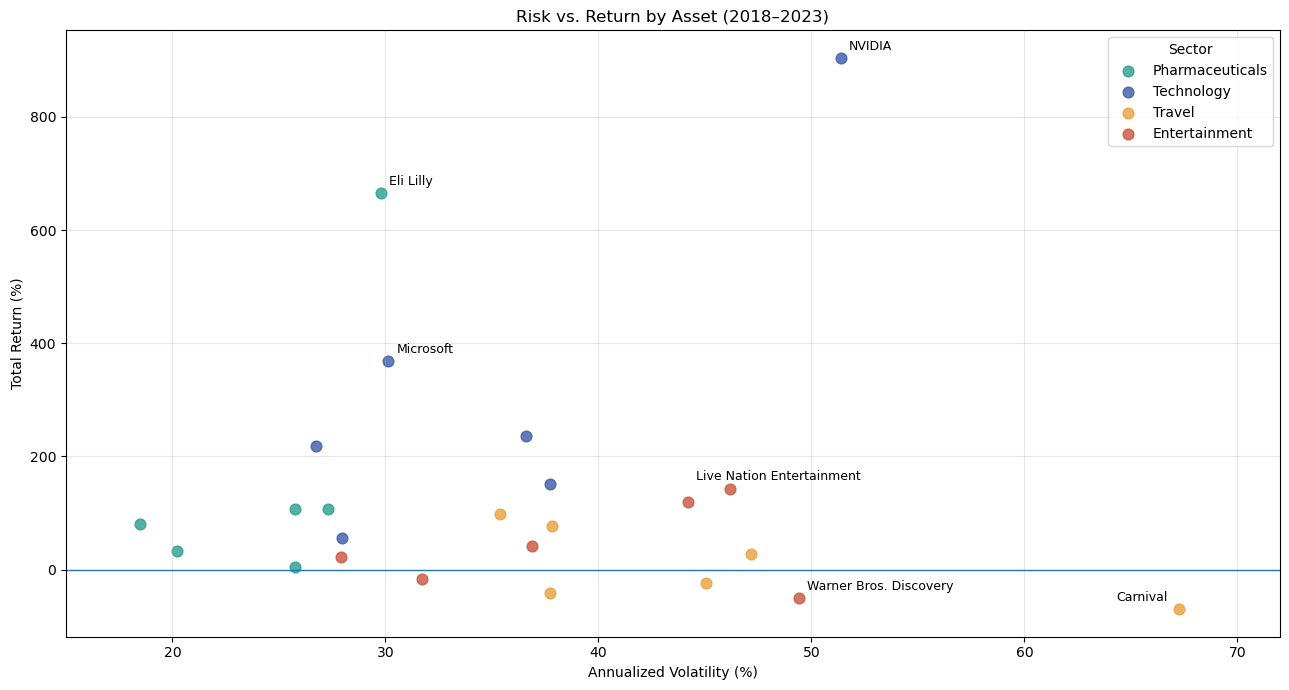

In [22]:
# Plot risk versus return
plt.figure(figsize=(13, 7))


# Calculate annualized volatility for each asset
asset_volatility = (
    volatility_data
    .groupby("Company")["DailyReturn"]
    .std()
    .mul(252 ** 0.5)
    .mul(100)
)

# Combine total return and volatility
risk_return = pd.DataFrame({
    "TotalReturn": company_return,
    "Volatility": asset_volatility
}).dropna()

# Add sector information
risk_return = (
    risk_return
    .reset_index()
    .merge(
        df_assets[["Company", "Sector"]],
        on="Company",
        how="left"
    )
)

for sector in risk_return["Sector"].unique():
    sector_data = risk_return[risk_return["Sector"] == sector]

    plt.scatter(
        sector_data["Volatility"],
        sector_data["TotalReturn"],
        label=sector,
        color=SECTOR_COLORS[sector],
        s=60,
        alpha=0.8
    )

# Label only selected key assets
key_assets = [
    "NVIDIA",
    "Eli Lilly",
    "Microsoft",
    "Live Nation Entertainment",
    "Warner Bros. Discovery",
    "Carnival"
]

for _, row in risk_return[
    risk_return["Company"].isin(key_assets)
].iterrows():

    x_offset = 6
    y_offset = 6

    # Move Carnival label to the left
    if row["Company"] == "Carnival":
        x_offset = -45

    # Move Live Nation Entertainment label higher
    if row["Company"] == "Live Nation Entertainment":
        y_offset = 16

    plt.annotate(
        row["Company"],
        (row["Volatility"], row["TotalReturn"]),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=9
    )

# Add a horizontal line at zero return
plt.axhline(0, linewidth=1)

plt.title("Risk vs. Return by Asset (2018–2023)")
plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Total Return (%)")

# Add a little extra space on the right side
plt.xlim(15, 72)

plt.legend(title="Sector")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

**Interpretation:** NVIDIA and Eli Lilly achieved the highest returns, while also showing moderate to high volatility. Carnival and Warner Bros. Discovery combined high volatility with negative total returns. The chart also shows that higher risk did not always result in higher returns.

## 17. Maximum Drawdown During the COVID Period

Maximum drawdown measures the largest decline from a previous peak.  
This analysis compares how severely each sector was affected during the COVID period from 2020 to 2021.

In [23]:
# Filter daily sector returns for the COVID period
covid_sector_returns = sector_daily_return[
    (sector_daily_return["Date"] >= "2020-01-01") &
    (sector_daily_return["Date"] < "2022-01-01")
].copy()

# Calculate cumulative performance for each sector
covid_sector_returns["CumulativeReturn"] = (
    covid_sector_returns
    .groupby("Sector")["DailyReturn"]
    .transform(lambda x: (1 + x).cumprod())
)

# Calculate the running maximum
covid_sector_returns["RunningMax"] = (
    covid_sector_returns
    .groupby("Sector")["CumulativeReturn"]
    .cummax()
)

# Calculate drawdown from the previous peak
covid_sector_returns["Drawdown"] = (
    covid_sector_returns["CumulativeReturn"] /
    covid_sector_returns["RunningMax"] - 1
)

# Find the maximum drawdown for each sector
max_drawdown = (
    covid_sector_returns
    .groupby("Sector")["Drawdown"]
    .min()
    .mul(100)
    .sort_values()
    .round(2)
)

max_drawdown

Sector
Travel            -62.05
Entertainment     -33.13
Technology        -30.45
Pharmaceuticals   -26.43
Name: Drawdown, dtype: float64

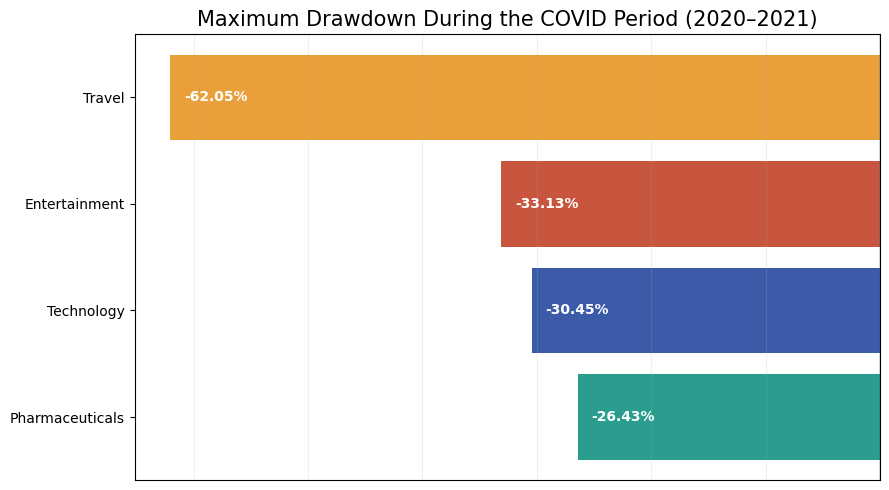

In [24]:
# Sort maximum drawdown values
sorted_drawdown = max_drawdown.sort_values()

# Use the predefined sector colors
colors = [
    SECTOR_COLORS[sector]
    for sector in sorted_drawdown.index
]

# Plot horizontally
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    sorted_drawdown.index,
    sorted_drawdown.values,
    color=colors
)

# Show the largest drawdown at the top
ax.invert_yaxis()

plt.title("Maximum Drawdown During the COVID Period (2020–2021)", fontsize=15)
plt.xlabel("")
plt.ylabel("")

# Remove x-axis numbers and tick marks
ax.tick_params(
    axis="x",
    bottom=False,
    labelbottom=False
)

# Keep subtle grid lines and zero line
plt.grid(axis="x", alpha=0.2)
plt.axvline(0, linewidth=1)

# Add drawdown values inside the bars
for bar, value in zip(bars, sorted_drawdown.values):
    ax.text(
        value + 1.2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        ha="left",
        va="center",
        color="white",
        fontweight="bold",
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Interpretation:** Travel experienced by far the largest maximum drawdown during the COVID period at **-62.05%**. Entertainment and Technology also recorded substantial declines of **-33.13%** and **-30.45%**, while Pharmaceuticals showed the smallest drawdown at **-26.43%**. This confirms that the Travel sector was the most severely affected during the COVID shock.

## 18. Build the Star Schema for SQL and Power BI

After completing the exploratory analysis, the cleaned data is transformed into a dimensional model for further analysis in SQL and Power BI.

The model contains:

- `dim_assets` — sector, company, ticker, and currency information;
- `dim_date` — calendar attributes for time-based analysis;
- `fact_prices` — daily OHLCV market observations linked to both dimensions.

### Star Schema

```text
dim_assets ──┐
             ├── fact_prices
dim_date ────┘
```


In [25]:
# Create the asset dimension
dim_assets = df_assets.reset_index(drop=True).copy()

dim_assets["AssetID"] = dim_assets.index + 1
dim_assets["Currency"] = "USD"

dim_assets = dim_assets[
    ["AssetID", "Sector", "Company", "Ticker", "Currency"]
]

dim_assets.head()


,AssetID,Sector,Company,Ticker,Currency
0,1,Technology,Microsoft,MSFT,USD
1,2,Technology,NVIDIA,NVDA,USD
2,3,Technology,Adobe,ADBE,USD
3,4,Technology,Salesforce,CRM,USD
4,5,Technology,Cisco,CSCO,USD


In [26]:
# Create the date dimension
dim_date = pd.DataFrame({
    "Date": pd.to_datetime(df_long["Date"].drop_duplicates().sort_values())
})

dim_date["DateID"] = range(1, len(dim_date) + 1)
dim_date["Year"] = dim_date["Date"].dt.year
dim_date["Quarter"] = dim_date["Date"].dt.quarter
dim_date["Month"] = dim_date["Date"].dt.month
dim_date["MonthName"] = dim_date["Date"].dt.month_name()
dim_date["Week"] = dim_date["Date"].dt.isocalendar().week
dim_date["Weekday"] = dim_date["Date"].dt.weekday + 1
dim_date["WeekdayName"] = dim_date["Date"].dt.day_name()

dim_date = dim_date[
    [
        "DateID",
        "Date",
        "Year",
        "Quarter",
        "Month",
        "MonthName",
        "Week",
        "Weekday",
        "WeekdayName"
    ]
].reset_index(drop=True)

dim_date.head()


,DateID,Date,Year,Quarter,Month,MonthName,Week,Weekday,WeekdayName
0,1,2018-01-02,2018,1,1,January,1,2,Tuesday
1,2,2018-01-03,2018,1,1,January,1,3,Wednesday
2,3,2018-01-04,2018,1,1,January,1,4,Thursday
3,4,2018-01-05,2018,1,1,January,1,5,Friday
4,5,2018-01-08,2018,1,1,January,2,1,Monday


In [27]:
# Create the price fact table and link it to both dimensions
fact_prices = (
    df_long
    .merge(
        dim_assets[["AssetID", "Ticker"]],
        on="Ticker",
        how="left"
    )
    .merge(
        dim_date[["DateID", "Date"]],
        on="Date",
        how="left"
    )
    .drop(columns=["Ticker", "Date"])
)

# Keep the fact-table columns in a clear order
fact_prices = fact_prices[
    ["AssetID", "DateID", "Open", "High", "Low", "Close", "Volume"]
]

fact_prices.head()


,AssetID,DateID,Open,High,Low,Close,Volume
0,8,1,67.405841,68.627113,67.135218,68.287102,4561300
1,9,1,49.645135,50.498144,49.320991,50.148411,10112800
2,3,1,175.850006,177.800003,175.259995,177.699997,2432800
3,13,1,68.382358,69.967578,68.163935,69.736649,11887500
4,17,1,60.894474,60.930710,60.332814,60.468700,2783800


## 19. Validate and Export the Data Model

The final checks confirm that every fact-table record is linked to a valid asset and date before the three tables are exported as CSV files.


In [28]:
# Validate the dimensional model
print("Fact table rows:", len(fact_prices))
print("Asset dimension rows:", len(dim_assets))
print("Date dimension rows:", len(dim_date))
print("Missing AssetID values:", int(fact_prices["AssetID"].isna().sum()))
print("Missing DateID values:", int(fact_prices["DateID"].isna().sum()))
print(
    "Duplicate AssetID-DateID combinations:",
    int(fact_prices.duplicated(["AssetID", "DateID"]).sum())
)


Fact table rows: 36216
Asset dimension rows: 24
Date dimension rows: 1509
Missing AssetID values: 0
Missing DateID values: 0
Duplicate AssetID-DateID combinations: 0


In [29]:
# Export the star-schema tables for SQL and Power BI
dim_assets.to_csv("dim_assets.csv", index=False)
dim_date.to_csv("dim_date.csv", index=False)
fact_prices.to_csv("fact_prices.csv", index=False)

print("Export completed:")
print(" - dim_assets.csv")
print(" - dim_date.csv")
print(" - fact_prices.csv")


Export completed:
 - dim_assets.csv
 - dim_date.csv
 - fact_prices.csv


## 20. Limitations

- Absolute share prices are not directly comparable across companies, which is why normalized values and percentage returns are used for the main comparisons.
- Three sectors contain one ETF, while Entertainment contains six individual companies, so the sector compositions are not perfectly equivalent.
- The Pre-COVID, COVID, and Post-COVID periods are predefined analytical categories rather than statistically identified structural breaks.
- The observed market developments cannot be attributed to the pandemic alone. Technology trends, interest rates, inflation, industry developments, and company-specific events also affected returns.
- The analysis covers 24 selected assets and is not intended to represent the entire market.
- The 24 assets were selected retrospectively rather than through a random sampling procedure, so selection bias may affect the results.
- `dim_date` contains trading days only because it is designed around the market dataset; it is not a continuous calendar table for standard DAX time-intelligence functions.


## 21. Summary and Key Findings

The exploratory analysis shows clear differences between the four selected sectors during 2018–2023.

- Using an **equal-weighted sector index**, **Technology** achieved the strongest full-period sector performance at approximately **322%**.
- **Pharmaceuticals** ranked second at approximately **166%**.
- **Entertainment** achieved approximately **43%** over the full period.
- **Travel** achieved approximately **11%** and experienced the strongest disruption during the COVID shock.
- **NVIDIA, Eli Lilly, and Microsoft** were the strongest individual performers.
- **Carnival and Warner Bros. Discovery** were the weakest individual performers.
- During the COVID period, Technology generated the highest average company return, while Travel was the only sector with a negative average return.
- The main sector performance, period-return, volatility, and drawdown analyses use equal weighting, so absolute share-price levels do not determine the sector results.

This notebook provides the Python-based exploratory analysis and prepares the dimensional data model used for the project's interactive Power BI dashboard.
